# Prosjekt 3

In [86]:
# Biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy

## Oppgave 1

### Oppgave 1a)

$ \frac{d^2 y}{(d x)^2}  = -4 * \sin(2x)$

Flytter dx^2 over på høyre side og integrerer to ganger.

$ \int{dy^2} = \int{-4*\sin(2x) dx^2} $

$dy = (4 * \frac{1}{2} \sin(2x) + C)dx$

$\int{dy} = \int{(4 * \frac{1}{2} \sin(2x) + C)dx}$ 


### Oppgave 1b)

### Oppgave 1c)

In [87]:
def f(x, y):
    return np.array([y[1], -4 * np.sin(2*x)])

def rk3 (x_start, x_slutt, y_0, h_0, tol, alpha, f):
   
    n, m = 0, 0                         # teller for antall godkjente steg (n) og ikke godkjente (m)
    x_verdier = np.array([x_start])     # array til x-verdier      
    y_verdier = np.array([y_0])         # array for y' og y
    h_verdier = np.array([])            # array til å lagre steglengde

    # Verdier som skal bli oppdatert i while-løkken
    x = x_start
    y = np.array(y_0)
    k1 = f(x,y)
    h = h_0
    
    while (x_slutt - x) > 0:

        # Velger steglengde
        h = min(h, x_slutt - x)

        k2 = f(x +h/2, y+ h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_neste = y + h* (2*k1 + 3*k2 + 4*k3)/9             # y[n+1]

        k4 = f(x + h, y_neste) 

        z_neste = y + 1/24*h*(7*k1 + 6*k2 + 8*k3 + 3*k4)    # z[n+1]

        est = np.linalg.norm(y_neste - z_neste)             # || y[n+1] - z[n+1] ||
        
        if est < tol:       # Akseptert steg
            x += h
            y = y_neste
            k1 = k4
            n += 1
            # Lagrer steget og tilhørende verdier:  
            x_verdier = np.append(x_verdier, x)
            y_verdier = np.append(y_verdier, [y], axis=0)
            h_verdier = np.append(h_verdier, h)
        else:               
            m += 1          # Ikke akseptert steg

        # Regn ut h_ny og la h = h_ny:
        h_ny = alpha * h *(tol/est)**(1/3)
        h = h_ny
    
    return x_verdier, y_verdier, h_verdier, n, m

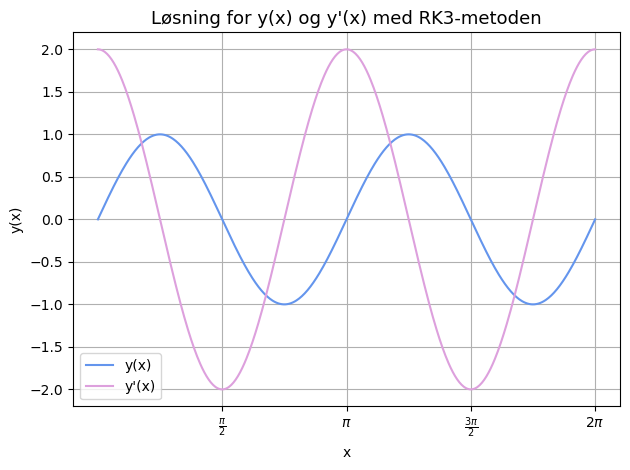

In [88]:
# Verdier
x_start = 0
x_slutt = 2*np.pi
h_0 = np.pi / 100
y_0 = np.array([0, 2])
alpha = 0.8
tol = 10e-7

x_verdier, y_verdier, h_verdier, n, m = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

# Plot for y(x) og y'(x)
plt.plot(x_verdier, y_verdier[:,0], color = "cornflowerblue", label = "y(x)")
plt.plot(x_verdier, y_verdier[:,1], color = "plum", label = "y'(x)")

plt.title("Løsning for y(x) og y'(x) med RK3-metoden", size = 13)
plt.xlabel("x")     
plt.ylabel("y(x)")

# Endrer x-aksen til å ha pi
ticks = [0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
labels = [r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
plt.xticks(ticks, labels)

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

De analytiske løsningene av $y(x)$ og $y'(x)$ er (fra oppgave 1a): 

$ y(x) = \sin(2x)$ og $y'(x) = 2*\cos(2x)$

Den numeriske løsningen av $y(x)$ (blå graf) er en sinuskurve med amplitude 1, den går mellom [-1, 1]. Den oscillerer dobbelt så raskt som $\sin(x)$, dette er fordi argumentet $2x$ gir den en periode på $\pi$. Derfor ser vi to svingninger på intervallet $[0, 2\pi]$.
Grafen til $y'(x)$ (lilla) er en cosinuskurve med samme frekvens og dobbel amplitude av $y(x)$. Ekstremalpunktene til $y(x)$ svarer til nullpunktene i $y'(x)$.

Den numeriske løsningen stemmer overens med den analytiske, og RK3-metoden gir en nøyaktig tilnærming i dette tilfellet.

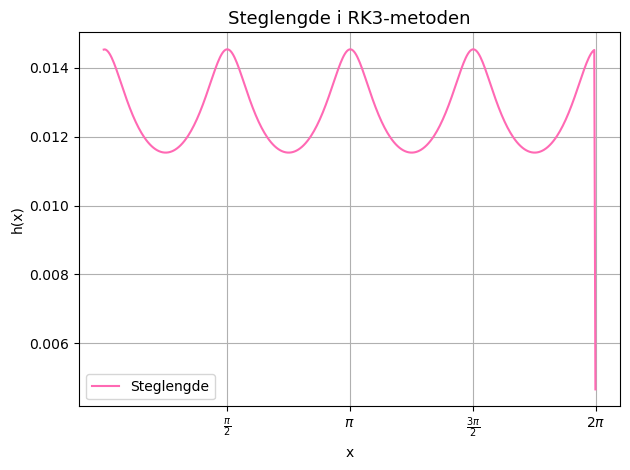

In [89]:
# Plot for steglengde
plt.plot(x_verdier[:-1], h_verdier, label = "Steglengde", color = "hotpink")
plt.title("Steglengde i RK3-metoden", size = 13)
plt.ylabel("h(x)")
plt.xlabel("x")

# Endrer x-aksen til å ha pi
ticks = [0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
labels = [r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
plt.xticks(ticks, labels)

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

Frem til siste steget varierer steglengden $h(x)$ tilnærmet periodisk. Dette skyldes at løsningen endrer seg med varierende krummning. Når det er stor krummning, blir den lokale feilen større for en gitt $h$ og RK3-metoden må derfor redusere $h$ for å holde feilen under toleransen. I omeråder der løsningen er tilnærmet linær kan metoden bruke større steglengder.

RK3-metoden sjekker steglengden på hver iterasjon slik at $h$ ikke overskrider sluttpunktet $x_{slutt}$. I hvert steg settes derfor $h = min(h, x_{slutt} - x)$. 
I det siste steget vil dette føre til at $h$ blir lik avstanden til sluttpunktet. Denne steglengden vil avvike fra det tidligere mønsteret og grafen får derfor en "dupp" i siste steg.

### Oppgave 1d

/var/folders/5l/k25732l95mjc4wxmpy3qmkkh0000gn/T/ipykernel_51262/4149814192.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


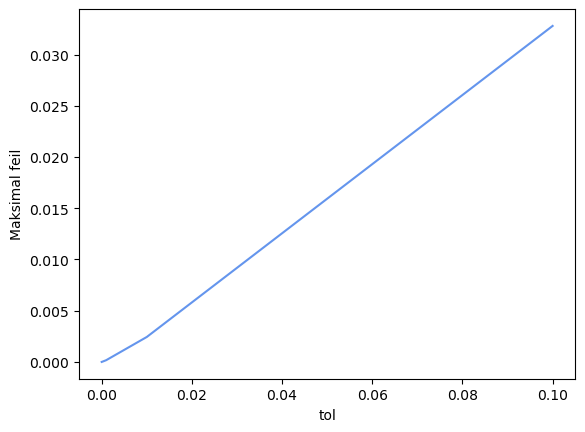

In [90]:
#tol_verdier = [10e-10, 10e-9, 10e-8, 10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 10e-2]
tol_verdier = np.logspace(-8, -2, 100)

def y_anal (x):
    return np.sin(2*x)

feil_liste = []
for tol in tol_verdier: 
    x_verdier, y_verdier, _, _, _ = rk3 (x_start, x_slutt, y_0, h_0, tol, alpha, f)
    y_anal_verdier = y_anal(x_verdier)
    error = np.abs(y_anal_verdier - y_verdier[:,0])
    feil_liste.append(np.max(error))

plt.loglog(tol_verdier, feil_liste, color = 'cornflowerblue') #eller burde jeg bruke loglog her??
plt.xlabel('tol')   
plt.ylabel('Maksimal feil')
plt.grid(True)
plt.legend()
plt.show()

/var/folders/5l/k25732l95mjc4wxmpy3qmkkh0000gn/T/ipykernel_51262/2296989345.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


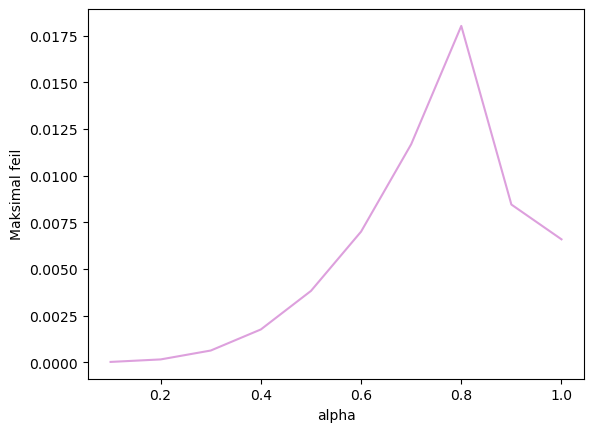

In [91]:
#alpha_verdier = [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
alpha_verdier = np.linspace(0.1, 1, 1000)

#Den analytiske løsningen fra oppgave 1a)
def y_anal (x):
    return np.sin(2*x)

feil_liste = []
for alpha in alpha_verdier: 
    x_verdier, y_verdier, _, _, _ = rk3 (x_start, x_slutt, y_0, h_0, tol, alpha, f)
    y_anal_verdier = y_anal(x_verdier)
    error = np.abs(y_anal_verdier - y_verdier[:,0])
    feil_liste.append(np.max(error))

plt.plot(alpha_verdier, feil_liste, color = 'plum') #eller burde jeg bruke loglog her??
plt.xlabel('alpha')   
plt.ylabel('Maksimal feil')
plt.grid(True)
plt.legend()
plt.show()

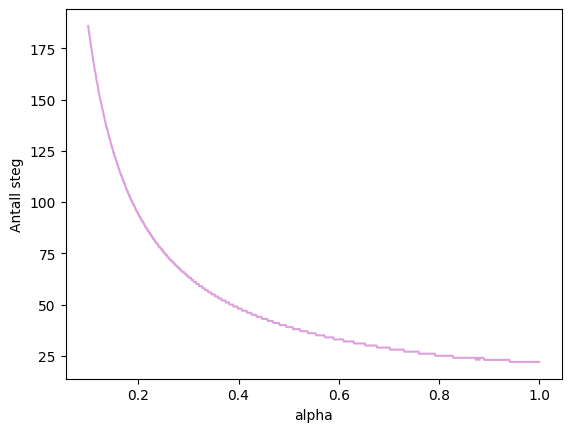

In [ ]:
#Denne grafen er kun for å se om steglengdene er fine
steg_liste = []
for alpha in alpha_verdier:
    x_verdier, y_verdier, _, _, _ = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)
    steg_liste.append(len(x_verdier))

plt.plot(alpha_verdier, steg_liste, color='plum')
plt.xlabel('alpha')
plt.ylabel('Antall steg')
plt.show()


###     Oppgave 1e)

In [92]:
def g(z):
    return z + np.sin(z) + np.cos(z)

def sekant_metoden (g, z0, z1, tol):
    z = [z0, z1]    # liste med startverdiene, z vil bli oppdatert med verdier som nærmer seg roten i while-løkken

    # første iterasjon, unngår indeksfeil i løkken (pga. abs(z[n-1] - z[n]))    
    n = 2
    z.append((z[n-2]*g(z[n-1]) - z[n-1]*g(z[n-2])) / (g(z[n-1]) - g(z[n-2])))

    # Itererer til forskjellen mellom z[n-1] - z[n] er mindre enn toleransen
    while abs(z[n-1] - z[n]) > tol:
        n+=1
        z.append((z[n-2]*g(z[n-1]) - z[n-1]*g(z[n-2])) / (g(z[n-1]) - g(z[n-2])))
        
    g_rot = z[-1]   # g_rot er z verdien som gir tilnærmet g(z) = 0
    return g_rot, z

In [93]:
# Startverdier og toleranse
z_0 = 0
z_1 = 4
tol = 1e-10

# Finner roten
g_rot, _ = sekant_metoden (g, z_0, z_1, tol)
print(f"Roten er z ≈ {g_rot:.5f}.")

# Verifisering
verdi = g(g_rot)
print(f"Setter vi tilbake i g får vi: g(z) ≈ {verdi:.3f}.")

# Min opprinlige forslag, litt lenger her men samtidig får med all relevant info, eller?
"""# Finner roten til g(z) = z + sin(z) + cos(z) 
g_rot = sekant_metoden (g, z_0, z_1, tol) 
print(f"Roten til g(z) = z + sin(z) + cos(z) er {g_rot:.5f}") 
# sjekker at g(z) = 0 
print(f"\nFor å verifisere at {g_rot:.5f} er roten til g(z), kan vi regne ut g(z):\ng({g_rot:.5f}) = {g(g_rot)}.\n\nAvrundet til 10 desimaler blir det: g({g_rot:.5f}) = {g(g_rot):.10f}")"""

Roten er z ≈ -0.45662.
Setter vi tilbake i g får vi: g(z) ≈ -0.000.


'# Finner roten til g(z) = z + sin(z) + cos(z) \ng_rot = sekant_metoden (g, z_0, z_1, tol) \nprint(f"Roten til g(z) = z + sin(z) + cos(z) er {g_rot:.5f}") \n# sjekker at g(z) = 0 \nprint(f"\nFor å verifisere at {g_rot:.5f} er roten til g(z), kan vi regne ut g(z):\ng({g_rot:.5f}) = {g(g_rot)}.\n\nAvrundet til 10 desimaler blir det: g({g_rot:.5f}) = {g(g_rot):.10f}")'


Ved bruk av sekantmetoden er en tilnærmet rot av funksjonen $g(z) = z + \sin(z) + \cos(z)$ lik $-0.45662$ (avrundet til 5 desimaler).
Når denne verdien settes inn i funksjonen uten avrunding, får vi at $g(z) \approx 0$ så lenge vi avrunder med minst $15$ desimaler. Dette bekrefter at metoden har konvergert mot et nullpunkt.

ER DETTE UNDER VITS I Å HA MED?:

Startverdiene og toleransen på $10^{-10}$ gir en svært nøyaktig måling på kort tid. 
Ved å variere toleransen observeres det at denne i stor grad bestemmer nøyaktigheten til løsningen:

$tol = 10^{-4}$ gir avrunding til 0 frem til 10 desimaler.

$tol = 10^{-3}$ gir avrunding til 0 frem til 6 desimaler.

$tol = 10^{-2}$ gir avrunding til 0 frem til 3 desimaler.

Dette viser at en strengere toleranse gir høyere presisjon. Ved å endre på startverdiene ser vi at de har mindre innvirkning på sluttresultatet, så lenge de ligger i et intervall hvor metoden konvergerer. 

### Oppgave 1f)

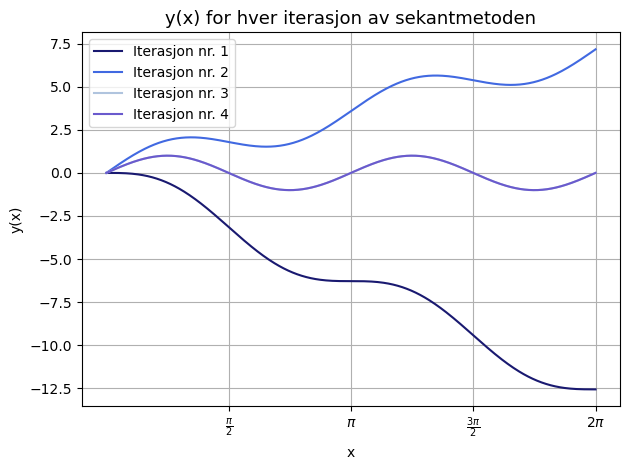

In [94]:
# Oppgitte startverdier
y_start = 0         # startpunkt [y(0) = 0]
y_slutt = 0         # endepunkt [y(2pi) = 0]
x_start = 0
x_slutt = 2*np.pi

# Parametere
b0 = 0          # b er startverdien y'(0) som gir yb(2pi) = 0
b1 = np.pi  
h_0 = np.pi / 100
alpha = 0.8
tol = 10e-7
# funksjonen f, er lik som i 1c) => gjenbruker samme

# 1.) Løser IVP for en gitt startverdi b = y'(0)
def løsning_IVP_med_b (b):
    y_0 = np.array([0, b])
    _, y_verdier_med_b, _, _, _ = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

    return y_verdier_med_b[-1, 0]   #sluttverdien y[2pi, b]

# 2.) Residualen F(b) = y[2pi, b] - y(2pi) 
def residual(b):
    return løsning_IVP_med_b(b) - y_slutt

# 3.) Finner hva b er med sekant_metoden fra 1e)
riktig_b, b_verdier_alle_iterasjoner = sekant_metoden(residual, b0, b1, tol)

# 4.) Løser IVP med RK3-metoden for hver b-verdi fra sekantmetoden
y_losninger = []
x_losninger = []

for b in b_verdier_alle_iterasjoner:

    ny_y_0 = np.array([0, b])
    x_verdier_midtid, y_verdier_midtid, _, _, _ = rk3(x_start, x_slutt, ny_y_0, h_0, tol, alpha, f)

    y_losninger.append(y_verdier_midtid)
    x_losninger.append(x_verdier_midtid)

# Plot
colors = ["midnightblue", "royalblue", "lightsteelblue", "slateblue" ]
for i in range(0, len(y_losninger)):
    plt.plot(x_losninger[i], y_losninger[i][:, 0], colors[i % len(colors)], label = f"Iterasjon nr. {i+1}")

plt.title("y(x) for hver iterasjon av sekantmetoden", size = 13)
plt.xlabel("x")     
plt.ylabel("y(x)")

# Endrer x-aksen til å ha pi
ticks = [0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
labels = [r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
plt.xticks(ticks, labels)

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

For hver iterasjon i sekantmetoden brukes $b = y'(0)$ som startverdi til å løse et IVP for $y(x)$ med RK3-metoden. Figuren viser løsningene $y(x)$ for hver iterasjon, i vårt tilfelle 4 iterasjoner. Målet er å finne b slik at randbetingelsen $y(2\pi) \approx 0$ oppfylles. Det er størst avvik i den første iterasjonen, mens iterasjon nummer $3$ og $4$ ender i   $0$. At kurvene for iterasjon $3$ og $4$ overlapper indikerer at sekantmetoden konvergerer svært raskt.

### Oppgave 1g)

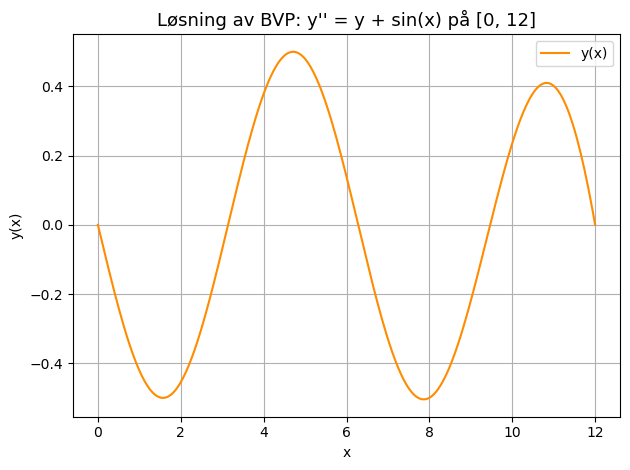

In [95]:
# Oppgitte startverdier
y_start = 0         # startpunkt [y(0) = 0]
y_slutt = 0         # endepunkt [y(12) = 0]
x_start = 0
x_slutt = 12

# Parametere
b0 = 0          # b er verdien som gir yb(12) = 0
b1 = 4  
h_0 = 12 / 200
alpha = 0.8
tol = 10e-7

# IVP 
def IVP(x, y):
    return np.array([y[1], y[0] + np.sin(x)])

# 1.) Løser IVP for en gitt startverdi b = y'(0)
def løsning_IVP_med_b (b):
    y_0 = np.array([0, b])
    _, y_verdier_med_b, _, _, _ = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, IVP)

    return y_verdier_med_b[-1, 0]   #sluttverdien y[12, b]

# 2.) Residualen F(b) = y[12, b] - y(12)
#     Funksjon fra 1f) residual(b)
def residual(b):
    return løsning_IVP_med_b(b) - y_slutt

# 3.) Finner hva b er med sekant_metoden fra 1e)
riktig_b, _ = sekant_metoden(residual, b0, b1, tol)

# 4.) Løser BVP med RK3 metoden og riktig_b
y_0_med_riktig_b = np.array([0, riktig_b])
x_verdier_g, y_verdier_g, h_g, n_g, m_g = rk3(x_start, x_slutt, y_0_med_riktig_b, h_0, tol, alpha, IVP)

# Plot for y(x)
plt.plot(x_verdier_g, y_verdier_g[:,0], color = "darkorange", label = "y(x)")

plt.title("Løsning av BVP: y'' = y + sin(x) på [0, 12]", size = 13)
plt.xlabel("x")    
plt.ylabel("y(x)")

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

### Oppgave 1h)

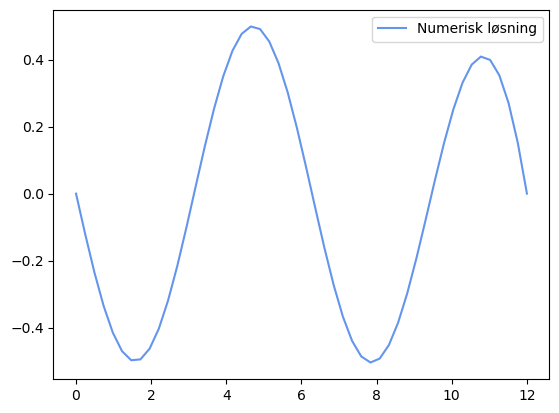

In [96]:
#Use the scipy function solve_bvp to solve eq. from task 1g)
from scipy.integrate import solve_bvp

def f(x, y):
    return [y[1], y[0]+ np.sin(x)]

#Grensebetingelser: y(0) = y(12) = 0
def bc(ya, yb):
    return [ya[0]-0, yb[0]-0]


x = np.linspace(0, 12)

y_init = np.zeros((2, x.size))
#y_init[0] = np.linspace(0, 1, x.size)
#y_init[1] = np.zeros(x.size)

sol = solve_bvp(f, bc, x, y_init)

x_plot = np.linspace(0, 12)
y_plot = sol.sol(x_plot)[0]

plt.plot(x_plot, y_plot, label = 'Numerisk løsning', color = 'cornflowerblue')
plt.legend()
plt.show()


